# 02 – EDA: Student Depression Dataset

Utforskande dataanalys inför modellering. Bygger på det **rensade och kodade** datasetet från
`01_Dataforberedelse.ipynb` (`student_depression_clean.csv`) - saknade värden, smutsig data och
irrelevanta kolumner är redan hanterade där.

Mål: förstå distributionerna och vilka variabler som verkar hänga ihop med `Depression`.

In [1]:
import pandas as pd                # DataFrames - tabellhantering, motsvarar ett kalkylark i kod
import numpy as np                 # numeriska beräkningar (används sällan direkt här, men standard att ha med)
import matplotlib.pyplot as plt    # grundläggande plottbibliotek
import seaborn as sns              # statistisk visualisering byggt ovanpå matplotlib, snyggare defaultstil

sns.set_theme(style="whitegrid")          # sätter en global, ljus rutnätsstil på alla plottar nedan
pd.set_option("display.max_columns", None)  # visa ALLA kolumner i output, inte trunkerat med "..."

## Visuell stil

Sätter en gemensam färgpalett och stil en gång här - alla diagram i resten av notebooken
ärver den automatiskt, så vi slipper styla om varje cell för sig.

In [2]:
# Fast, återanvändbar färgpalett för hela notebooken - istället för seaborns slumpmässiga
# defaultfärger. "blue"/"red" är ett CVD-validerat (colorblind-säkert) par: kontrasterar
# tydligt även för färgblinda läsare.
PALETTE = {
    "blue": "#2a78d6",     # kategori/serie 1, samt ena polen i diverging-skalor
    "red": "#e34948",      # kategori/serie 2, samt andra polen i diverging-skalor
    "orange": "#eb6834",   # tredje kategorin vid behov
    "neutral": "#f0efec",  # mittpunkt i diverging-skalor ("0"/"inget samband")
    "grid": "#e1e0d9",     # hårfina, återhållsamma gridlines
    "ink": "#0b0b0b",      # primär textfärg
    "muted": "#898781",    # sekundär text/axeletiketter
    "surface": "#fcfcfb",  # bakgrund
}

# rcParams sätts EN gång och gäller sedan automatiskt för varje efterföljande plt/sns-figur.
plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,     # bort med onödiga ramlinjer ("chart junk")
    "axes.spines.right": False,
    "text.color": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlelocation": "left",  # vänsterställd rubrik - vanlig konvention i "snygga" dashboards
})

sns.set_palette([PALETTE["blue"], PALETTE["red"], PALETTE["orange"]])

## 1. Ladda in datan

In [3]:
df = pd.read_csv("student_depression_clean.csv")  # ladda det REDAN RENSADE datasetet, inte rådatan
print(df.shape)   # (antal rader, antal kolumner)
df.head()          # notera att Gender, Sleep Duration, Dietary Habits m.fl. redan är siffror - se kodningsnyckeln nedan

(27842, 13)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,2,3,1,3.0,1.0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,2,2,0,3.0,2.0,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,1,3,0,9.0,1.0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,3,2,1,4.0,5.0,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,2,2,1,1.0,1.0,0,0


### Kodningsnyckel

Kategoriska variabler kodades om till siffror i `01_Dataforberedelse.ipynb`. Referens för att tolka
värdena i resten av denna notebook (t.ex. i korstabellerna nedan):

| Kolumn | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| `Gender` | Female | Male | | | |
| `Have you ever had suicidal thoughts ?` | No | Yes | | | |
| `Family History of Mental Illness` | No | Yes | | | |
| `Dietary Habits` | | Unhealthy | Moderate | Healthy | |
| `Sleep Duration` | | Less than 5h | 5-6h | 7-8h | More than 8h |

`City` lämnades som text (för hög kardinalitet för enkel kodning i detta steg).

In [4]:
# Visar datatyp per kolumn (int/float/object) samt hur många icke-tomma värden varje
# kolumn har. Bra första koll på var det finns saknade värden och om typerna stämmer
# (t.ex. att en siffra inte råkat bli inläst som text).
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27842 entries, 0 to 27841
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27842 non-null  int64  
 1   Age                                    27842 non-null  float64
 2   City                                   27842 non-null  str    
 3   Academic Pressure                      27842 non-null  float64
 4   CGPA                                   27842 non-null  float64
 5   Study Satisfaction                     27842 non-null  float64
 6   Sleep Duration                         27842 non-null  int64  
 7   Dietary Habits                         27842 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27842 non-null  int64  
 9   Work/Study Hours                       27842 non-null  float64
 10  Financial Stress                       27842 non-null  float64
 11  Family Histor

## 2. Saknade värden & extremvärden

In [5]:
missing = df.isnull().sum()      # räknar antal saknade (NaN) värden per kolumn
missing[missing > 0]              # sanity check - bör vara TOM eftersom 01_Dataforberedelse redan hanterat detta

Series([], dtype: int64)

In [6]:
# Statistiska mått (medelvärde, std, min, kvartiler, max) för alla NUMERISKA kolumner.
# Bra för att upptäcka orimliga min/max-värden (extremvärden/outliers), t.ex. en Age på 5 eller 90.
df.describe(include="number")

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000
mean,0.557252,25.820667,3.141656,7.656027,2.944149,2.399253,1.904605,0.632821,7.158286,3.140435,0.484161,0.585554
std,0.496720,4.906187,1.381729,1.470880,1.360890,1.126845,0.796905,0.482045,3.707158,1.437076,0.499758,0.492635
min,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,2.000000,6.290000,2.000000,1.000000,1.000000,0.000000,4.000000,2.000000,0.000000,0.000000
50%,1.000000,25.000000,3.000000,7.770000,3.000000,2.000000,2.000000,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,4.000000,8.920000,4.000000,3.000000,3.000000,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,59.000000,5.000000,10.000000,5.000000,4.000000,3.000000,1.000000,12.000000,5.000000,1.000000,1.000000


In [7]:
# Samma sak, fast för TEXT-kolumner: visar antal ifyllda värden, hur många unika
# kategorier, vanligaste värdet ("top") och hur många gånger det förekommer ("freq").
df.describe(include="object")

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_63941/3547002733.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,City
count,27842
unique,30
top,Kalyan
freq,1569


## 3. Kolumner som redan hanterats

`Profession`, `Work Pressure`, `Job Satisfaction`, `Degree` och `id` var mest tomma/irrelevanta
(majoriteten i datasetet är heltidsstudenter) och droppades redan i `01_Dataforberedelse.ipynb`.

## 4. Målvariabeln: balans

In [8]:
# normalize=True gör att vi får ANDELAR (0-1) istället för antal - dvs hur stor
# procentandel av studenterna som har Depression=0 respektive Depression=1.
# Avgör om målvariabeln är balanserad eller skev (viktigt inför modellval senare).
df["Depression"].value_counts(normalize=True)

Depression
1    0.585554
0    0.414446
Name: proportion, dtype: float64

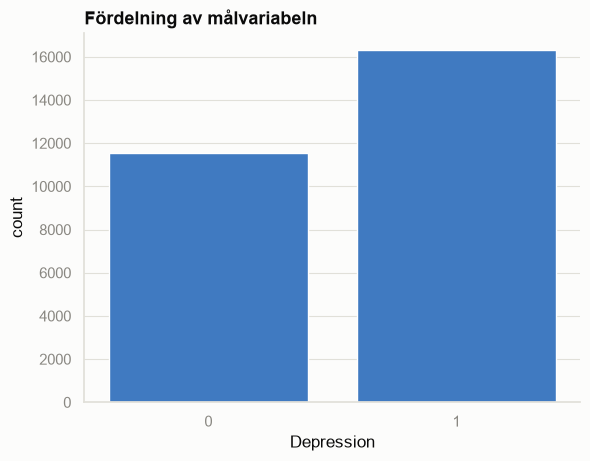

In [9]:
# Samma information som ovan, fast som stapeldiagram - lättare att ta in visuellt.
sns.countplot(data=df, x="Depression")
plt.title("Fördelning av målvariabeln")
plt.show()

## 5. Korrelationsöversikt

Första konkreta spadtaget: en heatmap över alla numeriska/kodade variabler, för att se
vad som hänger ihop med `Depression` (och med varandra) innan vi djupdyker i enskilda variabler.

**OBS:** korrelation fångar bara *linjära* samband - en låg siffra utesluter inte ett
verkligt mönster (se t.ex. Sleep Duration längre fram). Heatmapen är en kompass för var
vi ska titta närmare, inte facit.

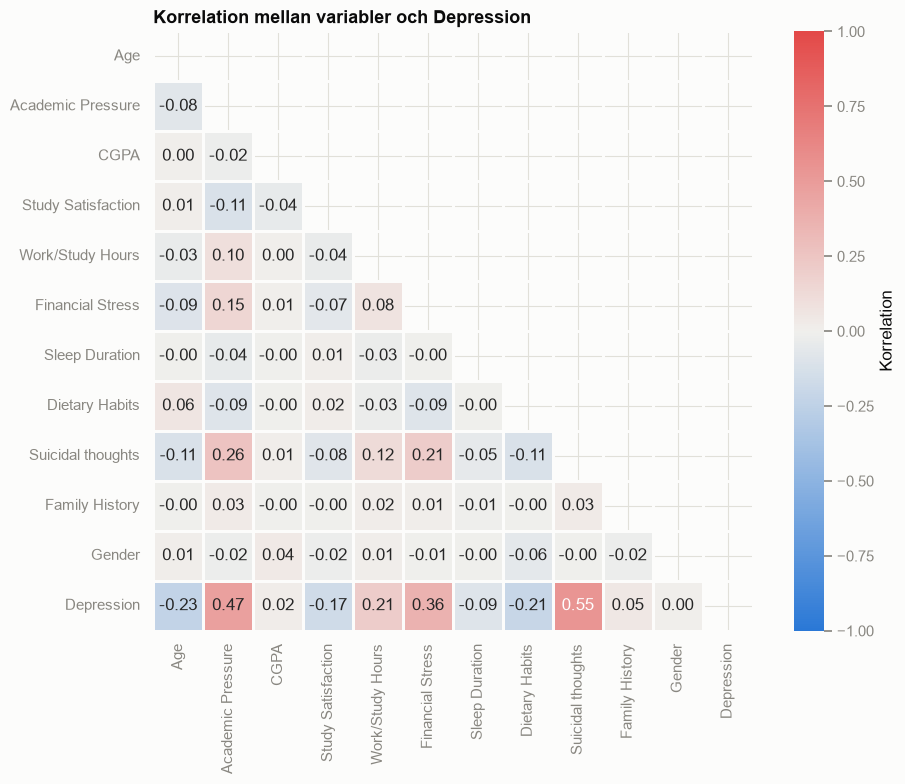

In [10]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = [
    "Age", "Academic Pressure", "CGPA", "Study Satisfaction", "Work/Study Hours",
    "Financial Stress", "Sleep Duration", "Dietary Habits",
    "Have you ever had suicidal thoughts ?", "Family History of Mental Illness",
    "Gender",
]
corr = df[numeric_cols + ["Depression"]].corr(numeric_only=True)

# Kortare visningsnamn ENDAST för diagrammet - de långa originalnamnen blir svårlästa
# som diagonala axeletiketter. Den underliggande datan/df:n ändras inte.
short_labels = {
    "Have you ever had suicidal thoughts ?": "Suicidal thoughts",
    "Family History of Mental Illness": "Family History",
}
corr = corr.rename(index=short_labels, columns=short_labels)

# Korrelation är en DIVERGING skala (-1 till +1, med 0 som en meningsfull mittpunkt) -
# så vi bygger en egen diverging colormap av vår egen palett (blå -> neutral grå -> röd)
# istället för en generisk/inbyggd. Samma logik som en diverging-skala alltid ska följa:
# två kulörer som läses som motsatser + en neutral mittpunkt, aldrig en regnbåge.
brand_diverging = LinearSegmentedColormap.from_list(
    "brand_diverging", [PALETTE["blue"], PALETTE["neutral"], PALETTE["red"]]
)

# Matrisen är symmetrisk (A↔B = B↔A) - vi döljer övre triangeln så vi inte visar
# samma information två gånger och halverar det visuella bruset.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",          # siffran i varje cell - i en heatmap ÄR siffran poängen
    cmap=brand_diverging, center=0, vmin=-1, vmax=1,
    linewidths=2, linecolor=PALETTE["surface"],  # tunn "luft" mellan cellerna istället för tjocka ramar
    square=True,
    cbar_kws={"label": "Korrelation"},
    ax=ax,
)
ax.set_title("Korrelation mellan variabler och Depression")
plt.tight_layout()
plt.show()

## 6. Academic Pressure & Financial Stress

Våra två starkaste och genuint oberoende signaler (Suicidal thoughts läggs åt sidan -
se diskussion ovan om varför den är för nära sammanflätad med själva depressions-
diagnosen för att räknas som en oberoende prediktor). Två separata diagram, ett per
variabel, för att hålla vart och ett lätt att tolka på egen hand.

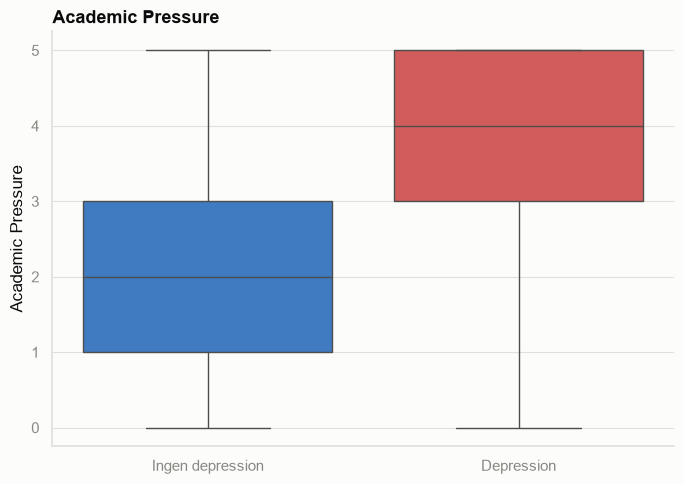

In [11]:
# Boxplot: Academic Pressure uppdelat på Depression. sns.set_palette([blue, red, orange])
# sattes i temacellen, så de två grupperna (0/1) får automatiskt samma blå/röd som resten
# av notebooken - vi behöver inte upprepa färgvalet här.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Academic Pressure", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])  # tydligare än råa 0/1-etiketter
ax.set_xlabel("")
ax.set_title("Academic Pressure")
plt.tight_layout()
plt.show()

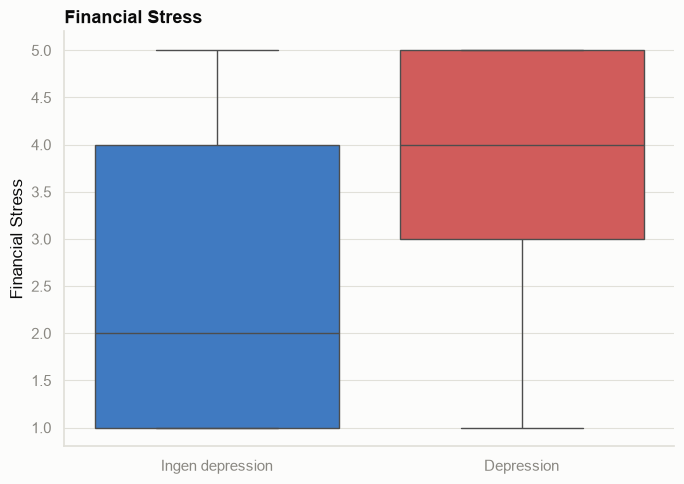

In [12]:
# Samma uppställning, nu för Financial Stress - egen figur, egen skala på y-axeln.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Financial Stress", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Financial Stress")
plt.tight_layout()
plt.show()

## 7. Slutsatser

**Målvariabelns balans.** 58.6% med Depression / 41.4% utan – rimligt balanserat. Ingen
särskild balanseringsteknik (t.ex. SMOTE) bör behövas inför modellering.

**Starkast kopplade variabler (korrelationsheatmapen).** Suicidal thoughts (0.55), Academic
Pressure (0.47) och Financial Stress (0.36) toppar. **Suicidal thoughts exkluderas dock från
modelleringen i steg 4** – kopplingen till Depression bedöms vara för nära sammanflätad med
själva diagnosen (jämför DSM-5-kriterierna för egentlig depression, där återkommande
suicidtankar är ett av symptomkriterierna) för att räknas som en oberoende, meningsfull
prediktor. Att inkludera den hade snarare mätt hur väl ett symptom korrelerar med sin egen
diagnos än gett en genuint prediktiv modell.

**Svaga/oviktiga variabler.** CGPA (0.02) och Gender (0.00) är i praktiken irrelevanta för
Depression i det här datasetet - kandidater att nedprioritera vid modellering.

**Bekräftat visuellt (boxplottarna).** Academic Pressure visade en tydligare, skarpare
separation mellan grupperna än Financial Stress, trots att båda har måttlig-till-stark
korrelation - en påminnelse om att korrelationens styrka inte alltid syns lika tydligt i en
visuell jämförelse.

**Implikationer för nästa steg.**
- Livsstilsvariabler (Sleep Duration, Dietary Habits, Academic Pressure, Financial Stress,
  Work/Study Hours) är kandidater till klustringssteget (steg 3).
- Numeriska variabler behöver **skalas** (t.ex. StandardScaler) innan PCA/klustring, eftersom
  de har mycket olika värdeintervall (Age 18-59 vs Dietary Habits 1-3) och skulle annars
  dominera resultatet omotiverat.
- Suicidal thoughts exkluderas helt från den supervised modelleringen i steg 4, av skälet
  ovan.